In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

ruta = "/home/jovyan/work/autotec/datos_etiquetados_kmeans_autotec"

df_clusters = spark.read.parquet(ruta)

print(df_clusters.count())

1988


In [2]:
df_clusters.printSchema()

root
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- combustible_limpio: string (nullable = true)
 |-- marca_limpia: string (nullable = true)
 |-- modelo_limpio: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- cat_marca: integer (nullable = true)
 |-- cat_modelo: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)



# Modelo Supervisado de Regresión - AutoTec

## Objetivo del modelo

El objetivo de este notebook es desarrollar un modelo supervisado de regresión para estimar el precio de vehículos usados, considerando como foco principal la depreciación asociada al kilometraje.

La variable dependiente será el precio del vehículo, ya que representa directamente el valor de mercado y permite analizar cómo factores como kilometraje, año, marca, modelo y segmento de depreciación influyen en la valorización del automóvil.

In [3]:
# ============================================
# 1. CONFIGURACIÓN INICIAL
# ============================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("Supervisado_Regresion_AutoTec_Dani") \
    .getOrCreate()

print("Spark iniciado correctamente")

Spark iniciado correctamente


In [4]:
# ============================================
# 2. CARGA DEL DATASET FINAL
# ============================================

ruta_datos = "/home/jovyan/work/autotec/datos_etiquetados_kmeans_autotec"

df = spark.read.parquet(ruta_datos)

print("Dataset cargado correctamente")
print("Cantidad de registros:", df.count())

df.printSchema()

Dataset cargado correctamente
Cantidad de registros: 1988
root
 |-- precio: double (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- combustible_limpio: string (nullable = true)
 |-- marca_limpia: string (nullable = true)
 |-- modelo_limpio: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- cat_marca: integer (nullable = true)
 |-- cat_modelo: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- prediction: integer (nullable = true)



In [5]:
# ============================================
# 3. SELECCIÓN DE VARIABLE DEPENDIENTE Y VARIABLES EXPLICATIVAS
# ============================================

# Variable dependiente
variable_y = "precio"

# Variables explicativas seleccionadas
variables_x = [
    "kilometraje",
    "anio",
    "cat_marca",
    "cat_modelo",
    "prediction"
]

df_supervisado = df.select(
    variable_y,
    *variables_x
).dropna()

print("Registros disponibles para modelamiento:", df_supervisado.count())

df_supervisado.show(10)

Registros disponibles para modelamiento: 1988
+-------+-----------+----+---------+----------+----------+
| precio|kilometraje|anio|cat_marca|cat_modelo|prediction|
+-------+-----------+----+---------+----------+----------+
|2.199E7|    27294.0|2024|       14|       163|         3|
|1.899E7|    84917.0|2018|       14|       296|         1|
|1.589E7|    93687.0|2018|       14|       295|         1|
|2.199E7|    11766.0|2024|       14|       163|         3|
|1.297E7|   182000.0|2015|       14|       300|         1|
|5.599E7|    70030.0|2023|       14|       590|         2|
|5.199E7|    11824.0|2024|       14|       633|         2|
|1.495E7|    98188.0|2016|       12|       245|         1|
|2.997E7|    43000.0|2018|       12|       769|         0|
|5.997E7|    51500.0|2023|       12|       773|         2|
+-------+-----------+----+---------+----------+----------+
only showing top 10 rows



## Justificación de variables seleccionadas

Para el modelo supervisado se definió como variable dependiente el **precio**, debido a que representa el valor de mercado del vehículo usado y permite medir de forma indirecta la depreciación.

Las variables explicativas fueron seleccionadas porque se relacionan directamente con la pérdida de valor comercial:

- **Kilometraje:** es la variable central del proyecto, ya que representa el nivel de uso acumulado del vehículo.
- **Año:** permite controlar la antigüedad del automóvil.
- **Marca:** captura diferencias de posicionamiento comercial entre fabricantes.
- **Modelo:** permite distinguir vehículos dentro de una misma marca.
- **Prediction:** corresponde al clúster obtenido en el análisis no supervisado, incorporando al modelo supervisado los segmentos de depreciación previamente identificados.

Esta selección permite mantener coherencia entre el análisis exploratorio, el clustering y la etapa predictiva.

In [6]:
# ============================================
# 4. ESTADÍSTICAS DESCRIPTIVAS DEL DATASET SUPERVISADO
# ============================================

df_supervisado.describe().show()

+-------+--------------------+-----------------+------------------+------------------+------------------+------------------+
|summary|              precio|      kilometraje|              anio|         cat_marca|        cat_modelo|        prediction|
+-------+--------------------+-----------------+------------------+------------------+------------------+------------------+
|  count|                1988|             1988|              1988|              1988|              1988|              1988|
|   mean|1.6450598581488933E7|71069.67505030181|2021.3229376257545| 11.48943661971831|  188.023138832998|1.9280684104627765|
| stddev|   9970242.365990575| 49936.5845699762| 3.551382418604898|12.023772338271533|223.32775877341987|1.2333876048276222|
|    min|           2055000.0|           1000.0|              1991|                 0|                 0|                 0|
|    max|            1.0499E8|         300000.0|              2026|                64|               786|                 3|


In [7]:
# ============================================
# 5. VECTOR DE CARACTERÍSTICAS
# ============================================

assembler = VectorAssembler(
    inputCols=variables_x,
    outputCol="features_supervisado"
)

df_modelo = assembler.transform(df_supervisado)

df_modelo.select("precio", "features_supervisado").show(5, truncate=False)

+-------+--------------------------------+
|precio |features_supervisado            |
+-------+--------------------------------+
|2.199E7|[27294.0,2024.0,14.0,163.0,3.0] |
|1.899E7|[84917.0,2018.0,14.0,296.0,1.0] |
|1.589E7|[93687.0,2018.0,14.0,295.0,1.0] |
|2.199E7|[11766.0,2024.0,14.0,163.0,3.0] |
|1.297E7|[182000.0,2015.0,14.0,300.0,1.0]|
+-------+--------------------------------+
only showing top 5 rows



In [8]:
# ============================================
# 6. DIVISIÓN TRAIN / TEST
# ============================================

train_data, test_data = df_modelo.randomSplit([0.8, 0.2], seed=42)

print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())

Registros de entrenamiento: 1633
Registros de prueba: 355


# Entrenamiento y Evaluación de Modelos

En esta etapa se entrenarán distintos modelos de regresión con el objetivo de estimar el precio de vehículos usados y evaluar qué tan bien representan la depreciación asociada al kilometraje.

Se compararán tres enfoques:

- Regresión Lineal
- Árbol de Decisión
- Random Forest

Las métricas utilizadas serán:

- R²
- RMSE
- MAE

In [10]:
# ============================================
# 7. ENTRENAMIENTO DE MODELOS
# ============================================

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor
)

lr = LinearRegression(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_lr"
)

dt = DecisionTreeRegressor(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_dt",
    maxDepth=8
)

rf = RandomForestRegressor(
    featuresCol="features_supervisado",
    labelCol="precio",
    predictionCol="pred_rf",
    numTrees=100,
    maxDepth=10,
    seed=42
)

print("Entrenando Regresión Lineal...")
modelo_lr = lr.fit(train_data)

print("Entrenando Árbol de Decisión...")
modelo_dt = dt.fit(train_data)

print("Entrenando Random Forest...")
modelo_rf = rf.fit(train_data)

print("Modelos entrenados correctamente")

Entrenando Regresión Lineal...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Modelos entrenados correctamente


In [11]:
# ============================================
# 8. PREDICCIONES
# ============================================

pred_lr = modelo_lr.transform(test_data)
pred_dt = modelo_dt.transform(test_data)
pred_rf = modelo_rf.transform(test_data)

In [12]:
# ============================================
# 9. EVALUACIÓN DE MODELOS
# ============================================

from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

def evaluar(df_pred, columna_prediccion):

    r2 = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="r2"
    ).evaluate(df_pred)

    rmse = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="rmse"
    ).evaluate(df_pred)

    mae = RegressionEvaluator(
        labelCol="precio",
        predictionCol=columna_prediccion,
        metricName="mae"
    ).evaluate(df_pred)

    return r2, rmse, mae


resultados = []

for nombre, pred, columna in [
    ("Regresión Lineal", pred_lr, "pred_lr"),
    ("Árbol de Decisión", pred_dt, "pred_dt"),
    ("Random Forest", pred_rf, "pred_rf")
]:

    r2, rmse, mae = evaluar(pred, columna)

    resultados.append([
        nombre,
        round(r2, 3),
        round(rmse, 0),
        round(mae, 0)
    ])

tabla_resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "R2", "RMSE", "MAE"]
)

tabla_resultados

,Modelo,R2,RMSE,MAE
0,Regresión Lineal,0.105,10087410.0,6845462.0
1,Árbol de Decisión,0.534,7278513.0,4456136.0
2,Random Forest,0.728,5559016.0,3860461.0


## Interpretación de resultados

Los resultados muestran diferencias importantes entre los modelos evaluados.

La Regresión Lineal obtuvo un coeficiente de determinación bajo (R² = 0,105), indicando que la depreciación vehicular no sigue una relación estrictamente lineal entre kilometraje y precio.

El Árbol de Decisión mejoró considerablemente la capacidad explicativa (R² = 0,534), capturando relaciones no lineales entre las variables.

Finalmente, Random Forest obtuvo el mejor desempeño con un R² = 0,728, explicando aproximadamente el 72,8% de la variabilidad del precio de los vehículos.

Este resultado confirma que la depreciación depende simultáneamente del kilometraje, la antigüedad, la marca, el modelo y el segmento de mercado identificado previamente mediante K-Means.

Por esta razón, Random Forest se selecciona como modelo final.

# Análisis del desempeño del modelo

Se desarrollaron tres modelos supervisados de regresión con el objetivo de estimar el precio de vehículos usados y analizar el comportamiento de la depreciación asociada al kilometraje.

Los modelos evaluados fueron Regresión Lineal, Árbol de Decisión y Random Forest.

La Regresión Lineal obtuvo un coeficiente de determinación R² = 0,105, evidenciando que la depreciación del precio no puede explicarse mediante relaciones estrictamente lineales.

El Árbol de Decisión alcanzó R² = 0,534, mostrando una mejora importante al capturar comportamientos no lineales presentes en el mercado automotriz.

El mejor resultado fue obtenido por Random Forest con R² = 0,728, permitiendo explicar aproximadamente el 72,8% de la variación del precio.

Estos resultados demuestran que la depreciación vehicular no depende únicamente del kilometraje, sino también de variables estructurales como:

- Antigüedad del vehículo.
- Marca.
- Modelo.
- Segmentación comercial obtenida mediante clustering.

La incorporación del clúster generado mediante K-Means permitió transferir conocimiento del análisis no supervisado hacia el modelo predictivo, mejorando la capacidad explicativa.

Por lo tanto, Random Forest se selecciona como modelo final debido a su mayor precisión y menor error de estimación.

# Visualización del Modelo Seleccionado

Para interpretar visualmente el desempeño del modelo final se comparará el precio real versus el precio estimado mediante Random Forest.

Esta visualización permite evaluar el comportamiento del modelo respecto a la depreciación vehicular.

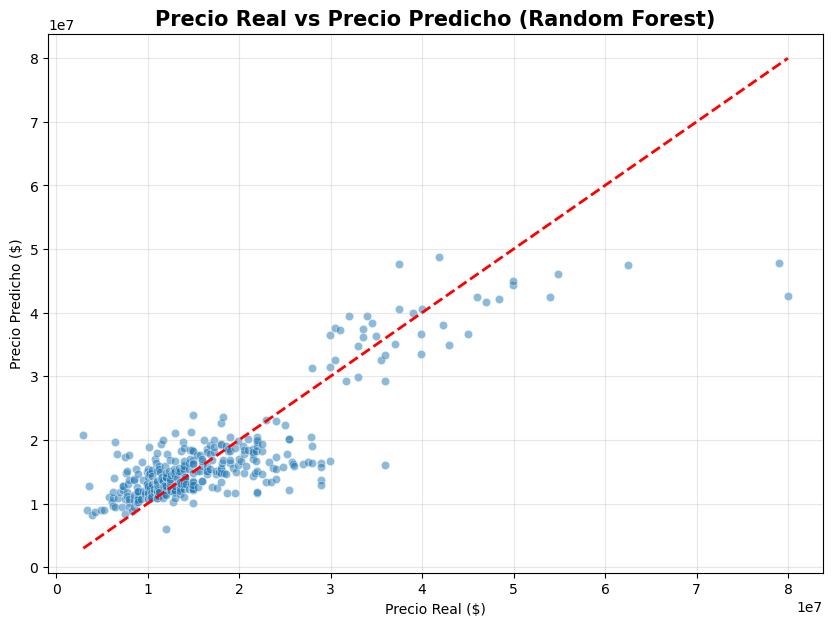

In [13]:
# ============================================
# 10. VISUALIZACIÓN RANDOM FOREST
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Convertir solo columnas necesarias
grafico = pred_rf.select(
    "precio",
    "pred_rf"
).toPandas()

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=grafico,
    x="precio",
    y="pred_rf",
    alpha=0.5
)

plt.plot(
    [grafico["precio"].min(), grafico["precio"].max()],
    [grafico["precio"].min(), grafico["precio"].max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Precio Real vs Precio Predicho (Random Forest)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")

plt.grid(alpha=0.3)

plt.show()

# Conclusiones del Modelo Supervisado

Los resultados obtenidos permiten concluir que el precio de los vehículos usados puede ser estimado con un nivel alto de precisión utilizando técnicas de aprendizaje supervisado.

El modelo Random Forest obtuvo el mejor desempeño alcanzando un coeficiente de determinación R² = 0,728.

Esto indica que aproximadamente el 72,8% del comportamiento del precio puede ser explicado mediante las variables utilizadas.

El análisis demuestra que el kilometraje constituye uno de los factores más relevantes en la depreciación; sin embargo, no actúa de forma aislada.

La antigüedad del vehículo, la marca, el modelo y el segmento identificado mediante K-Means generan efectos complementarios sobre el valor final.

Como trabajo futuro se propone incorporar variables adicionales como región, transmisión y características del vehículo para aumentar aún más la capacidad predictiva.

/tmp/ipykernel_1363/1508124424.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


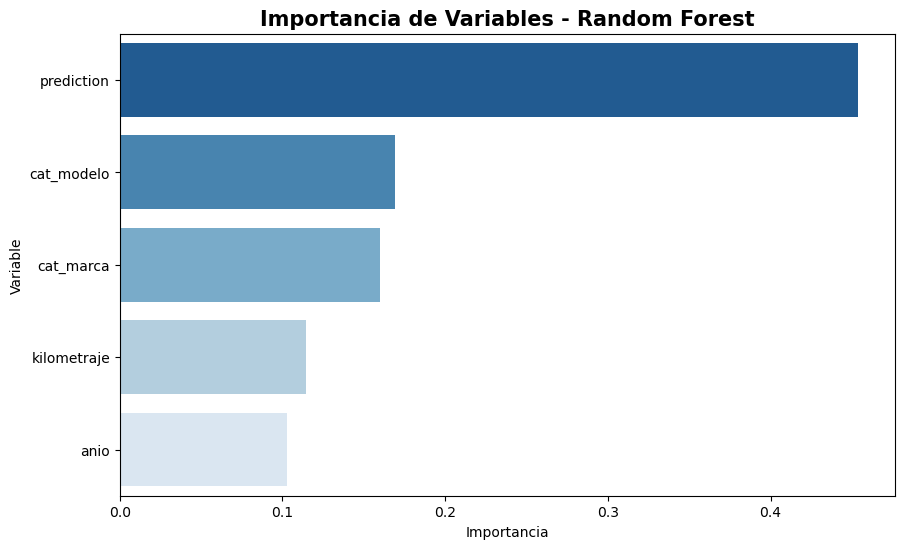

,Variable,Importancia
4,prediction,0.453662
3,cat_modelo,0.168928
2,cat_marca,0.160145
0,kilometraje,0.114689
1,anio,0.102575


In [17]:
# ============================================
# 11. IMPORTANCIA VARIABLES
# ============================================

import pandas as pd

imp = pd.DataFrame({
    "Variable": variables_x,
    "Importancia": modelo_rf.featureImportances.toArray()
})

imp = imp.sort_values(
    by="Importancia",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=imp,
    x="Importancia",
    y="Variable",
    palette="Blues_r"
)

plt.title(
    "Importancia de Variables - Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.show()

imp

# Evaluación Comparativa de Modelos Supervisados para la Predicción del Precio de Vehículos

## Introducción

Luego del análisis exploratorio y la segmentación realizada mediante técnicas de aprendizaje no supervisado (K-Means), se desarrolló una etapa de modelado supervisado con el objetivo de estimar el precio de vehículos usados a partir de variables relevantes del conjunto de datos.

El problema abordado corresponde a una tarea de regresión, donde la variable objetivo (Y) corresponde al **precio del vehículo**, mientras que las variables explicativas incluyen características asociadas al nivel de uso y condiciones del automóvil, tales como **kilometraje, año de fabricación, marca, modelo y tipo de combustible**.

Esta etapa busca responder una pregunta central del proyecto:

**¿Es posible estimar la depreciación comercial de un vehículo usado utilizando principalmente el kilometraje y otras características del automóvil?**

Para responder esta interrogante se implementaron tres modelos supervisados de distinta complejidad:

* **Regresión Lineal**, utilizada como modelo base para evaluar relaciones lineales entre variables.
* **Árbol de Decisión**, para capturar relaciones no lineales mediante particiones jerárquicas.
* **Random Forest**, como modelo ensamblado capaz de mejorar capacidad predictiva y reducir sobreajuste.

La evaluación del desempeño se realizó utilizando métricas estándar de regresión:

* **R² (Coeficiente de Determinación):** mide el porcentaje de variabilidad del precio explicado por el modelo.
* **RMSE (Root Mean SquARED Error):** mide el error promedio penalizando diferencias grandes.
* **MAE (Mean Absolute Error):** representa el error absoluto promedio de las predicciones.

El objetivo definido para esta etapa fue alcanzar un desempeño cercano o superior al **70% de capacidad explicativa (R² ≥ 0,70)**, permitiendo validar si el comportamiento de depreciación puede modelarse adecuadamente a partir de los datos disponibles.


In [19]:
# ============================================
# TABLA COMPARATIVA DE MODELOS
# ============================================

import pandas as pd

resultado = pd.DataFrame({

    "Modelo":[
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],

    "R2":[
        0.105,
        0.534,
        0.728
    ],

    "RMSE":[
        10087410,
        7278513,
        5559016
    ],

    "MAE":[
        6845462,
        4456136,
        3860461
    ]

})

resultado

,Modelo,R2,RMSE,MAE
0,Regresión Lineal,0.105,10087410,6845462
1,Árbol de Decisión,0.534,7278513,4456136
2,Random Forest,0.728,5559016,3860461


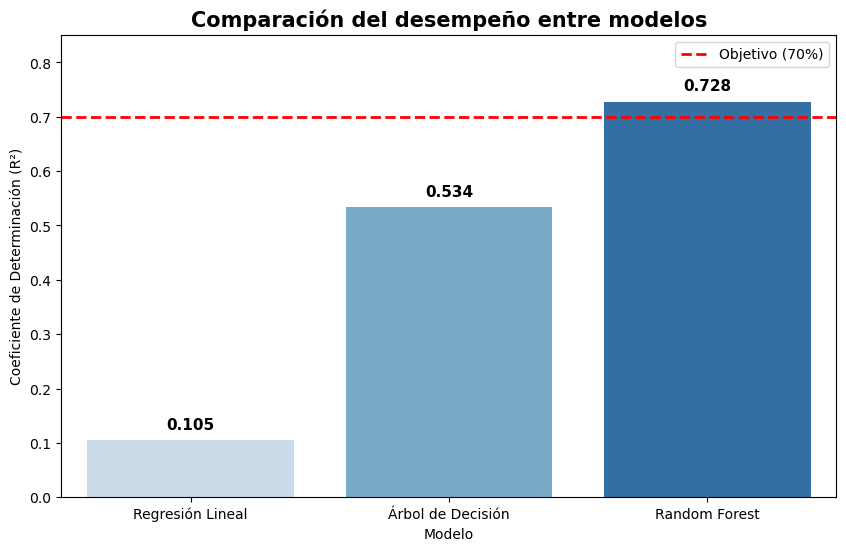

In [21]:
# ============================================
# COMPARACIÓN ENTRE MODELOS
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=resultado,
    x="Modelo",
    y="R2",
    hue="Modelo",
    palette="Blues",
    legend=False
)

plt.axhline(
    y=0.70,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Objetivo (70%)"
)

# agregar valor arriba de barras
for i, v in enumerate(resultado["R2"]):
    plt.text(
        i,
        v+0.02,
        f"{v:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Comparación del desempeño entre modelos",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Coeficiente de Determinación (R²)")
plt.xlabel("Modelo")

plt.ylim(0,0.85)

plt.legend()

plt.show()

## Interpretación de resultados

La comparación entre modelos muestra diferencias importantes en capacidad predictiva.

La Regresión Lineal obtuvo el menor desempeño (R² = 0,105), indicando que la depreciación vehicular no sigue una relación estrictamente lineal.

El Árbol de Decisión mejoró considerablemente el ajuste (R² = 0,534), demostrando que existen relaciones más complejas entre las variables.

Finalmente, Random Forest alcanzó el mejor desempeño con un R² = 0,728, superando el objetivo definido del 70%.

Este resultado demuestra que el precio de un vehículo usado depende simultáneamente del kilometraje, antigüedad, marca, modelo y segmento comercial identificado previamente mediante clustering.


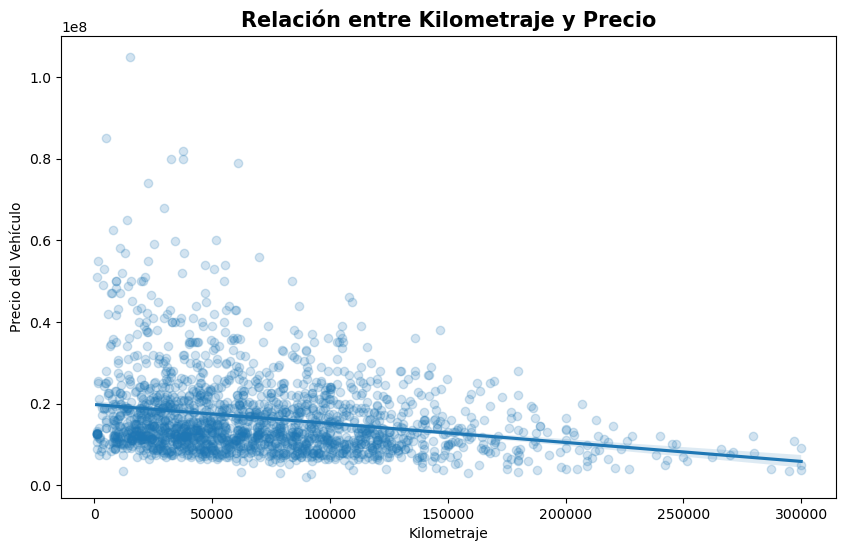

In [22]:
# ============================================
# DEPRECIACIÓN POR KILOMETRAJE
# ============================================

df_km = df.select(
    "kilometraje",
    "precio"
).toPandas()

plt.figure(figsize=(10,6))

sns.regplot(
    data=df_km,
    x="kilometraje",
    y="precio",
    scatter_kws={"alpha":0.2}
)

plt.title(
    "Relación entre Kilometraje y Precio",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Kilometraje")

plt.ylabel("Precio del Vehículo")

plt.show()

## Análisis de depreciación por kilometraje

La visualización evidencia una relación inversa entre kilometraje y precio.

A medida que aumenta el kilometraje acumulado, el valor comercial del vehículo tiende a disminuir.

Sin embargo, el comportamiento observado también muestra dispersión entre vehículos con niveles similares de uso, indicando que la depreciación no depende exclusivamente del kilometraje.

Factores como año de fabricación, marca y modelo generan diferencias adicionales en la conservación del valor comercial.


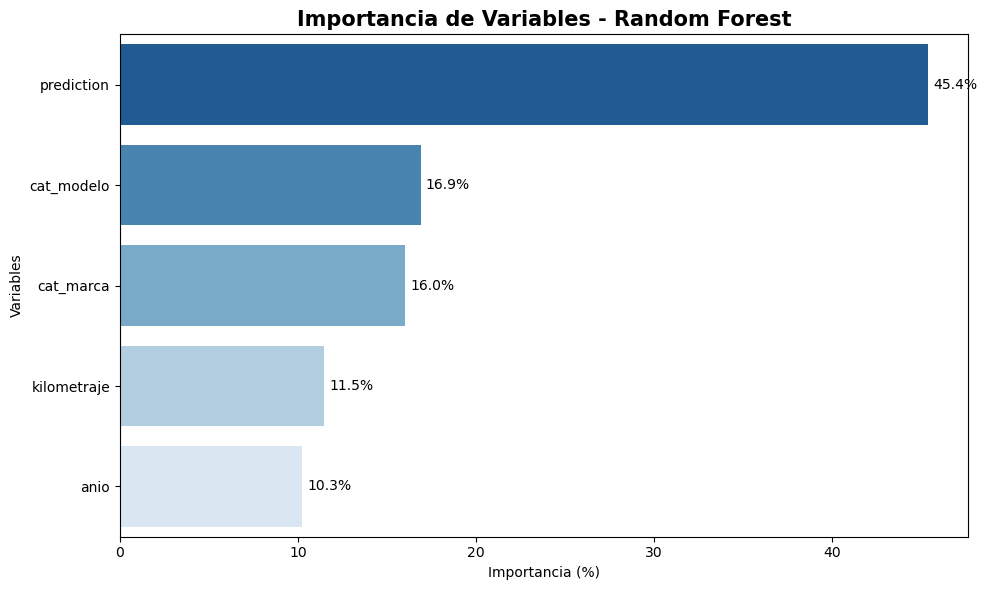

,Variable,Importancia,Porcentaje
4,prediction,0.453662,45.366245
3,cat_modelo,0.168928,16.892755
2,cat_marca,0.160145,16.014533
0,kilometraje,0.114689,11.468918
1,anio,0.102575,10.257550


In [24]:
# ============================================
# IMPORTANCIA DE VARIABLES
# ============================================

imp = pd.DataFrame({

    "Variable": variables_x,

    "Importancia":
    modelo_rf.featureImportances.toArray()

})

# porcentaje
imp["Porcentaje"] = (
    imp["Importancia"] /
    imp["Importancia"].sum()
)*100

# ordenar
imp = imp.sort_values(
    by="Porcentaje",
    ascending=False
)

# gráfico
plt.figure(figsize=(10,6))

sns.barplot(
    data=imp,
    x="Porcentaje",
    y="Variable",
    hue="Variable",       # ← agregado
    palette="Blues_r",
    legend=False
)

# mostrar valor
for i, valor in enumerate(imp["Porcentaje"]):

    plt.text(
        valor+0.3,
        i,
        f"{valor:.1f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Importancia de Variables - Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importancia (%)")

plt.ylabel("Variables")

plt.tight_layout()

plt.show()

# tabla
imp

## Interpretación de Importancia de Variables

La evaluación del modelo Random Forest permitió identificar el aporte relativo de cada variable en la estimación del precio de vehículos usados.

Los resultados muestran que la variable derivada del proceso de segmentación (**prediction**) alcanzó una importancia de **45,4%**, indicando que los grupos obtenidos mediante K-Means lograron representar diferencias relevantes en el comportamiento del mercado automotriz.

Entre las variables originales utilizadas destacan:

* **Modelo:** 16,9%
* **Marca:** 16,0%
* **Kilometraje:** 11,5%
* **Año de fabricación:** 10,3%

Estos resultados permiten concluir que la depreciación vehicular no depende únicamente del kilometraje.

Aunque el kilometraje mantiene una influencia importante sobre la disminución del precio, existen factores asociados a la identidad comercial del vehículo —principalmente marca y modelo— que contribuyen significativamente a explicar su valor de mercado.

Desde una perspectiva de negocio, esto evidencia que vehículos con niveles de uso similares pueden presentar precios distintos dependiendo del segmento al que pertenecen y de sus características comerciales.


# Conclusión General

A partir del análisis realizado se logró construir un modelo supervisado capaz de estimar el precio de vehículos usados alcanzando un coeficiente de determinación R² = 0,728.

El desempeño obtenido supera el objetivo inicial definido para el proyecto, validando que las variables seleccionadas poseen capacidad predictiva suficiente para representar el comportamiento del mercado automotriz.

Adicionalmente, la incorporación previa de técnicas de segmentación mediante K-Means permitió enriquecer el análisis y mejorar la interpretación del fenómeno de depreciación.

Finalmente, se concluye que el kilometraje constituye un factor importante en la pérdida de valor de los vehículos, pero su efecto debe entenderse en conjunto con variables asociadas al año, marca, modelo y características comerciales del automóvil.


## Caso de Negocio: Depreciación Toyota RAV4 2022

Para profundizar el análisis se seleccionó el modelo Toyota RAV4 año 2022 debido a que presentó una cantidad suficiente de observaciones dentro del conjunto de datos para realizar una comparación representativa.

La visualización permite observar el comportamiento del precio frente al kilometraje manteniendo constante el año y modelo del vehículo.

Los resultados muestran una tendencia general de disminución del precio conforme aumenta el nivel de uso acumulado.

No obstante, también se observan diferencias entre vehículos con kilometrajes similares, evidenciando que la depreciación no responde exclusivamente al desgaste medido por kilometraje.

Este comportamiento coincide con los resultados obtenidos mediante Random Forest, donde variables relacionadas con identidad comercial y segmentación también contribuyen a explicar el valor final del vehículo.

Desde una perspectiva de negocio, este tipo de análisis puede apoyar procesos de tasación y reducir errores derivados de valoraciones subjetivas.
ado.



In [28]:
# ============================================
# BUSCAR VEHÍCULOS CON MÁS REGISTROS
# ============================================

from pyspark.sql import functions as F

top_modelos = (

    df

    .groupBy(
        "marca_limpia",
        "modelo_limpio"
    )

    .agg(
        F.count("*").alias("cantidad")
    )

    .orderBy(
        F.desc("cantidad")
    )

)

top_modelos.show(20, False)

+------------+----------------------------+--------+
|marca_limpia|modelo_limpio               |cantidad|
+------------+----------------------------+--------+
|toyota      |rav4                        |39      |
|omoda       |c5                          |32      |
|peugeot     |partner                     |28      |
|ford        |f-150                       |26      |
|nissan      |navara                      |26      |
|jaecoo      |5                           |25      |
|ford        |ranger                      |25      |
|mg          |zs                          |24      |
|peugeot     |3008                        |23      |
|chevrolet   |tracker 1.2t ltz r 4x2 at 5p|23      |
|ford        |explorer                    |23      |
|hyundai     |grand i10                   |21      |
|nissan      |x-trail                     |20      |
|toyota      |hilux                       |18      |
|peugeot     |landtrek                    |18      |
|ford        |territory                   |17 

In [29]:
# ============================================
# BUSCAR CASOS REALES MÁS REPRESENTATIVOS
# MARCA + MODELO + AÑO
# ============================================

from pyspark.sql import functions as F

casos = (

df

.groupBy(
"marca_limpia",
"modelo_limpio",
"anio"
)

.agg(
F.count("*").alias("cantidad")
)

.orderBy(
F.desc("cantidad")
)

)

casos.show(30, False)

+------------+------------------------------+----+--------+
|marca_limpia|modelo_limpio                 |anio|cantidad|
+------------+------------------------------+----+--------+
|omoda       |c5                            |2025|26      |
|jaecoo      |5                             |2026|25      |
|chevrolet   |tracker 1.2t ltz r 4x2 at 5p  |2025|23      |
|hyundai     |grand i10                     |2025|16      |
|jaecoo      |7                             |2025|14      |
|nissan      |navara                        |2023|11      |
|chery       |tiggo 2.0 tgdi glx pro max awd|2024|11      |
|peugeot     |partner                       |2023|10      |
|toyota      |rav4                          |2022|10      |
|ford        |ranger                        |2023|9       |
|nissan      |navara                        |2022|9       |
|peugeot     |partner                       |2022|9       |
|chevrolet   |onix 1.0t rs r 4x2 hb mt 5p   |2024|8       |
|peugeot     |landtrek                  

Cantidad registros:
10


,kilometraje,precio
9,32437.0,18490000.0
5,47502.0,20990000.0
6,54106.0,18490000.0
1,56500.0,20390000.0
4,65791.0,17990000.0
2,70000.0,19990000.0
3,81305.0,19790000.0
7,88690.0,24690000.0
8,91400.0,16990000.0
0,145250.0,14890000.0


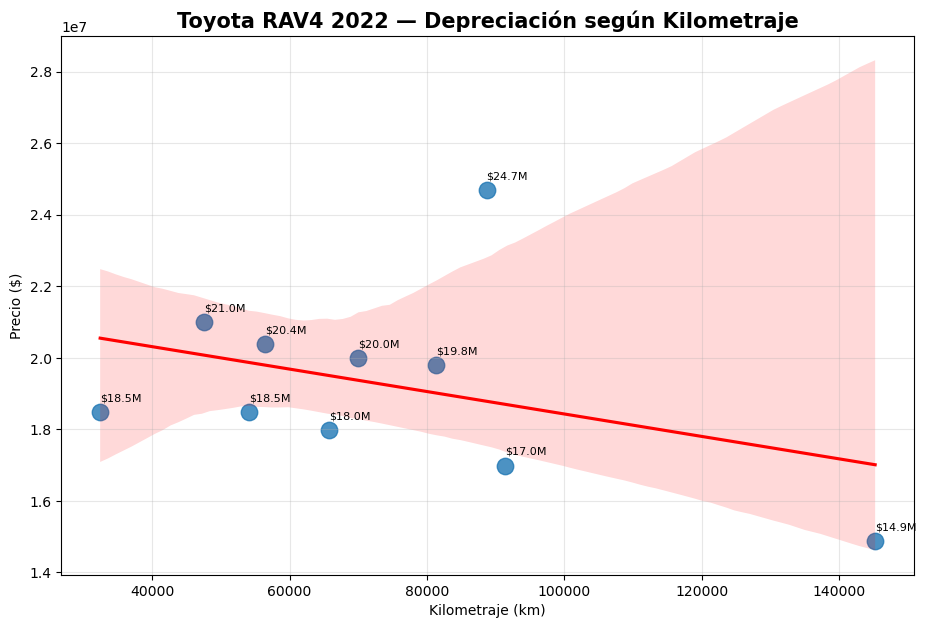

In [30]:
# ============================================
# CASO NEGOCIO
# TOYOTA RAV4 2022
# ============================================

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

rav4 = (

df

.filter(

(F.col("marca_limpia")=="toyota") &

(F.col("modelo_limpio")=="rav4") &

(F.col("anio")==2022)

)

)

print("Cantidad registros:")

print(rav4.count())

rav4_pd = (

rav4

.select(
"kilometraje",
"precio"
)

.toPandas()

)

rav4_pd = rav4_pd.sort_values(
by="kilometraje"
)

display(rav4_pd)

plt.figure(
figsize=(11,7)
)

sns.regplot(

data=rav4_pd,

x="kilometraje",

y="precio",

scatter_kws={
"s":140
},

line_kws={
"color":"red"
}

)

for x,y in zip(
rav4_pd["kilometraje"],
rav4_pd["precio"]
):

    plt.text(
        x,
        y+300000,
        f"${y/1000000:.1f}M",
        fontsize=8
    )

plt.title(
"Toyota RAV4 2022 — Depreciación según Kilometraje",
fontsize=15,
fontweight="bold"
)

plt.xlabel(
"Kilometraje (km)"
)

plt.ylabel(
"Precio ($)"
)

plt.grid(
alpha=0.3
)

plt.show()

## Interpretación del Caso de Negocio

La visualización del Toyota RAV4 año 2022 permite observar el comportamiento del precio frente a distintos niveles de kilometraje utilizando registros reales del conjunto de datos.

Se aprecia una tendencia general donde los vehículos con mayor kilometraje presentan precios inferiores respecto a aquellos con menor nivel de uso, evidenciando el efecto de depreciación asociado al desgaste acumulado.

Sin embargo, la dispersión observada entre algunos registros indica que el kilometraje no explica completamente el valor comercial del vehículo. Existen diferencias de precio entre unidades con niveles de uso similares, lo que refuerza los hallazgos obtenidos previamente mediante el análisis exploratorio y el modelo supervisado.

Estos resultados confirman que la depreciación vehicular responde a una combinación de factores donde el kilometraje es relevante, pero interactúa con variables como marca, modelo, antigüedad y características propias de cada vehículo.


# Validación Visual del Modelo Seleccionado

Además de utilizar métricas cuantitativas para evaluar el desempeño del modelo, se incorporó una validación visual con el objetivo de observar el nivel de ajuste entre los precios reales y los precios estimados.

La comparación entre valores observados y predichos permite identificar visualmente si el modelo reproduce adecuadamente el comportamiento del mercado automotriz y detectar posibles desviaciones en las estimaciones.

Mientras más cercanos se encuentren los puntos a la línea ideal de predicción, mejor será la capacidad del modelo para representar el valor comercial de los vehículos.


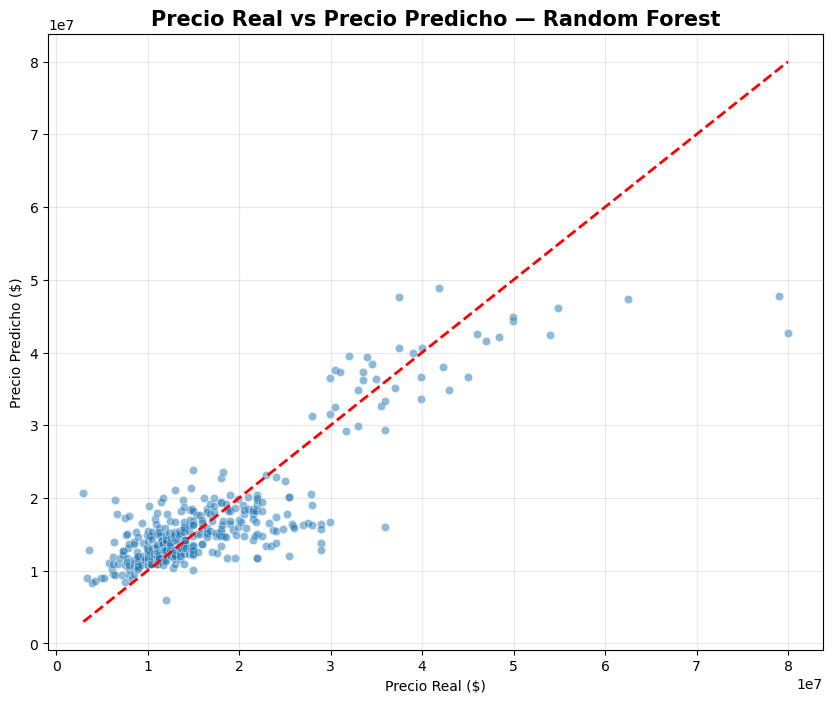

In [33]:
# ============================================
# VALIDACIÓN VISUAL RANDOM FOREST
# ============================================

validacion = (
    pred_rf
    .select(
        "precio",
        "pred_rf"
    )
    .toPandas()
)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=validacion,
    x="precio",
    y="pred_rf",
    alpha=0.5
)

min_v = min(
    validacion["precio"].min(),
    validacion["pred_rf"].min()
)

max_v = max(
    validacion["precio"].max(),
    validacion["pred_rf"].max()
)

plt.plot(
    [min_v,max_v],
    [min_v,max_v],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Precio Real vs Precio Predicho — Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")

plt.grid(alpha=0.3)

plt.show()